In [31]:
import pandas as pd
import numpy as np
url = "https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv"
#columns = ["Wine","Alcohol","Malic.acid","Ash","Acl","Mg","Phenols","Flavanoids","Nonflavanoid.phenols","Proanth","Color.int","Hue","OD","Proline"]

wine = pd.read_csv(url)
wine.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Q1

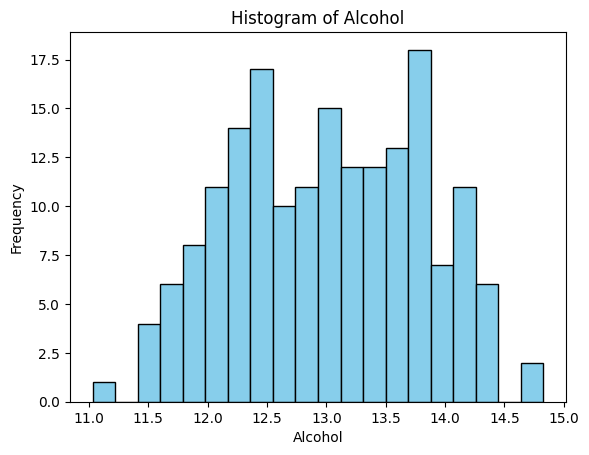

In [32]:
import matplotlib.pyplot as plt
plt.hist(wine['Alcohol'],bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.title('Histogram of Alcohol')
plt.show()

Q2

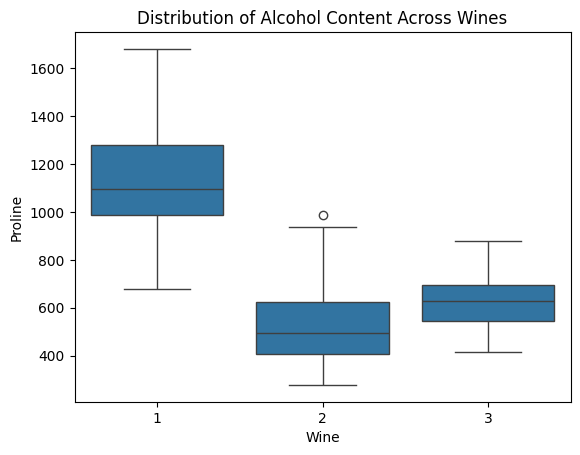

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x= wine["Wine"], y = wine["Proline"], data=wine)
plt.title('Distribution of Alcohol Content Across Wines')
plt.show()

Q3

                          Wine   Alcohol  Malic.acid       Ash       Acl  \
Wine                  1.000000 -0.328222    0.437776 -0.049643  0.517859   
Alcohol              -0.328222  1.000000    0.094397  0.211545 -0.310235   
Malic.acid            0.437776  0.094397    1.000000  0.164045  0.288500   
Ash                  -0.049643  0.211545    0.164045  1.000000  0.443367   
Acl                   0.517859 -0.310235    0.288500  0.443367  1.000000   
Mg                   -0.209179  0.270798   -0.054575  0.286587 -0.083333   
Phenols              -0.719163  0.289101   -0.335167  0.128980 -0.321113   
Flavanoids           -0.847498  0.236815   -0.411007  0.115077 -0.351370   
Nonflavanoid.phenols  0.489109 -0.155929    0.292977  0.186230  0.361922   
Proanth              -0.499130  0.136698   -0.220746  0.009652 -0.197327   
Color.int             0.265668  0.546364    0.248985  0.258887  0.018732   
Hue                  -0.617369 -0.071747   -0.561296 -0.074667 -0.273955   
OD          

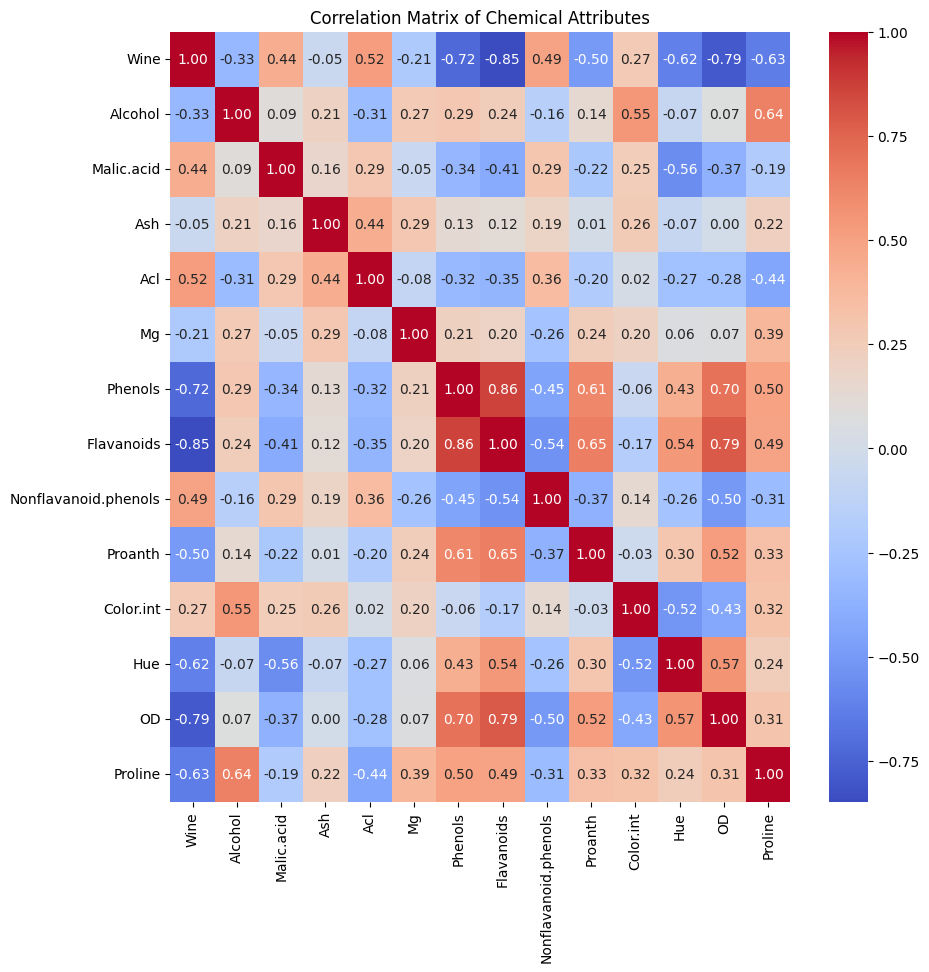

In [60]:
correlation_matrix = wine.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Chemical Attributes')
plt.show()

Q4

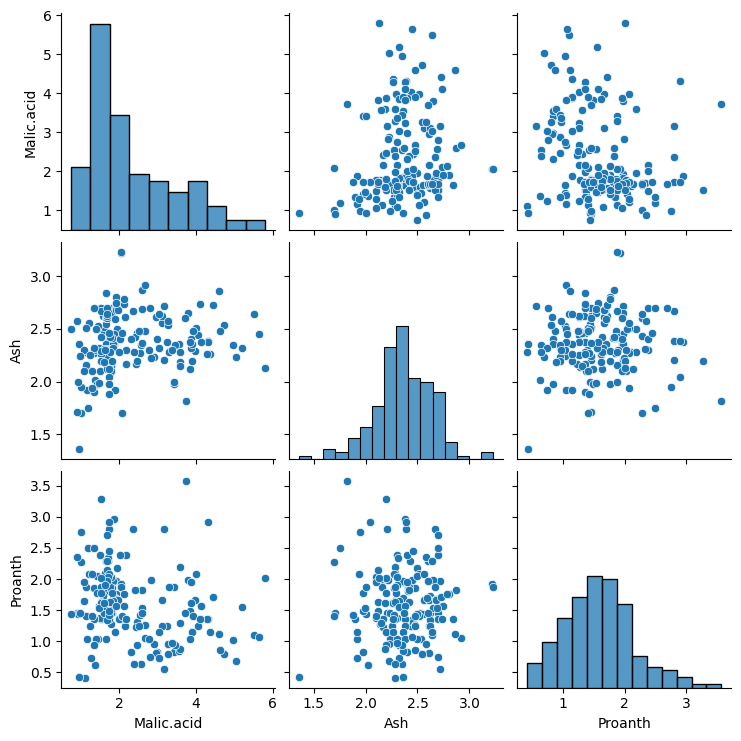

In [40]:
import seaborn as sns
sns.pairplot(wine[['Malic.acid', 'Ash', 'Proanth']])
plt.show()

Q5

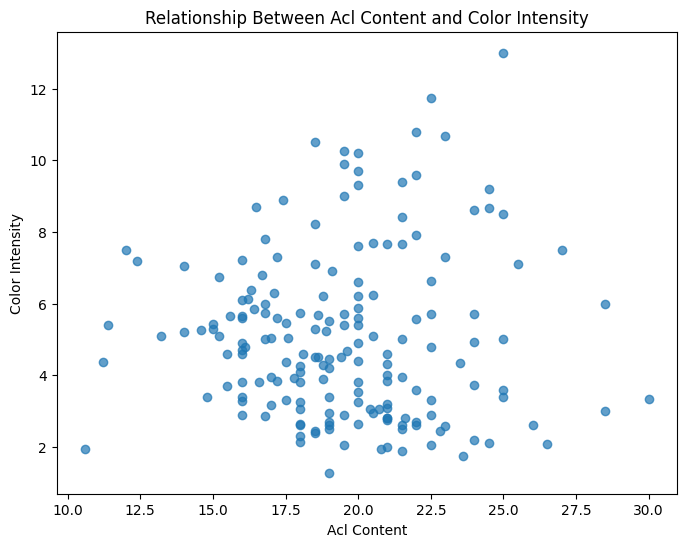

In [41]:
plt.figure(figsize=(8, 6))
plt.scatter(wine['Acl'], wine['Color.int'], alpha=0.7)
plt.xlabel('Acl Content')
plt.ylabel('Color Intensity')
plt.title('Relationship Between Acl Content and Color Intensity')
plt.show()

Q6

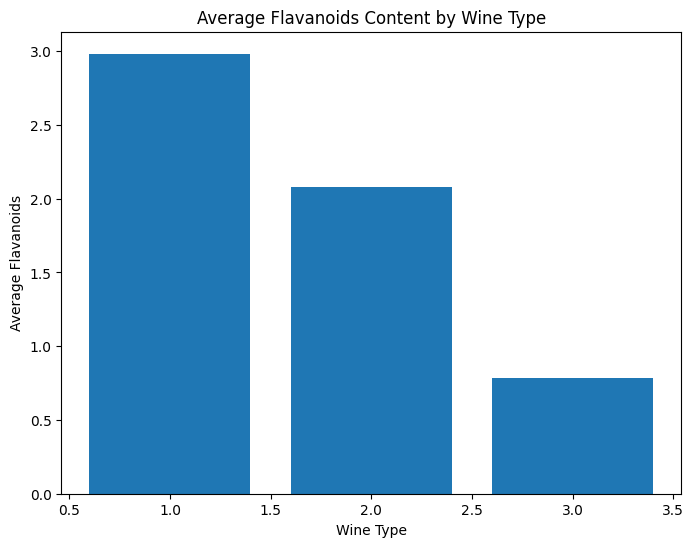

Wine
1    2.982373
2    2.080845
3    0.781458
Name: Flavanoids, dtype: float64


In [42]:
average_flavanoids_by_wine = wine.groupby('Wine')['Flavanoids'].mean()
plt.figure(figsize=(8, 6))
plt.bar(average_flavanoids_by_wine.index, average_flavanoids_by_wine.values)
plt.xlabel('Wine Type')
plt.ylabel('Average Flavanoids')
plt.title('Average Flavanoids Content by Wine Type')
plt.show()

print(average_flavanoids_by_wine)

Q7

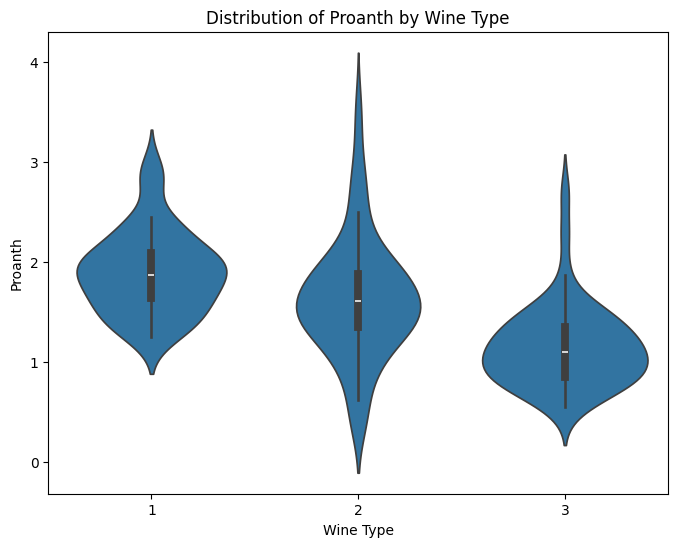

In [43]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Wine', y='Proanth', data=wine)
plt.xlabel('Wine Type')
plt.ylabel('Proanth')
plt.title('Distribution of Proanth by Wine Type')
plt.show()

Clustering

Q8

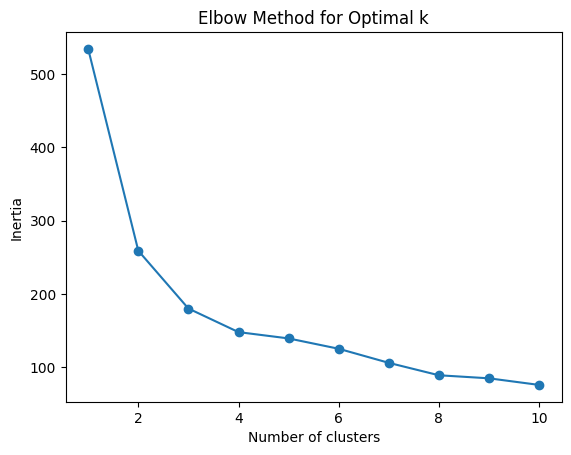

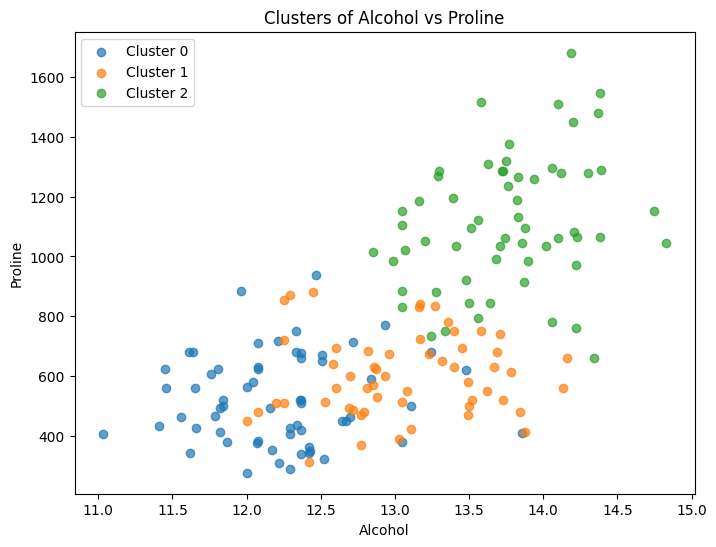

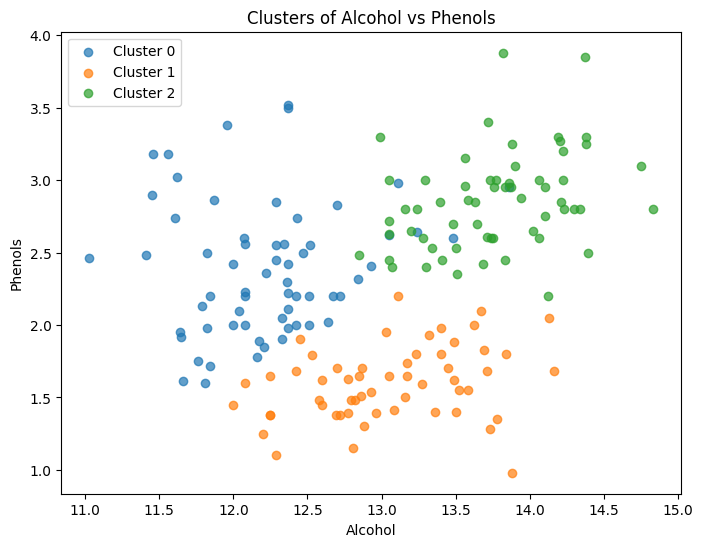

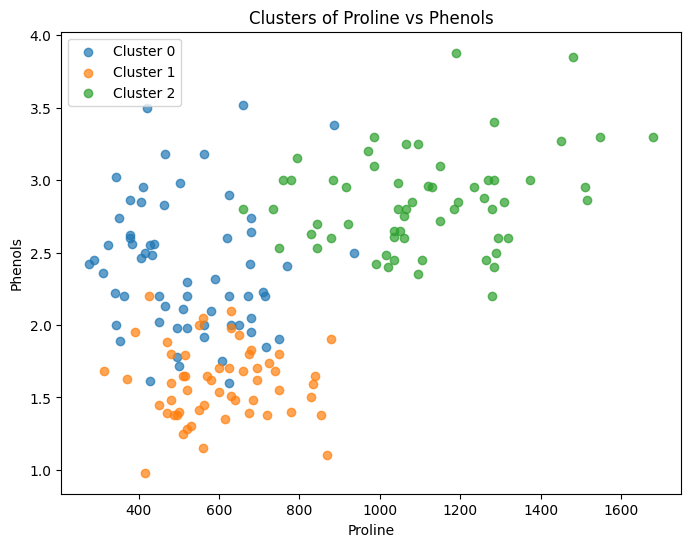

In [44]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
features = wine[['Alcohol', 'Proline', 'Phenols']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_features)
cluster_labels = kmeans.labels_
wine['Cluster'] = cluster_labels

feature_combinations = [['Alcohol', 'Proline'], ['Alcohol', 'Phenols'], ['Proline', 'Phenols']]
for feature1, feature2 in feature_combinations:
    plt.figure(figsize=(8, 6))
    for cluster in range(n_clusters):
        plt.scatter(
            wine[wine['Cluster'] == cluster][feature1],
            wine[wine['Cluster'] == cluster][feature2],
            label=f'Cluster {cluster}',
            alpha=0.7
        )
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f'Clusters of {feature1} vs {feature2}')
    plt.legend()
    plt.show()

Q9

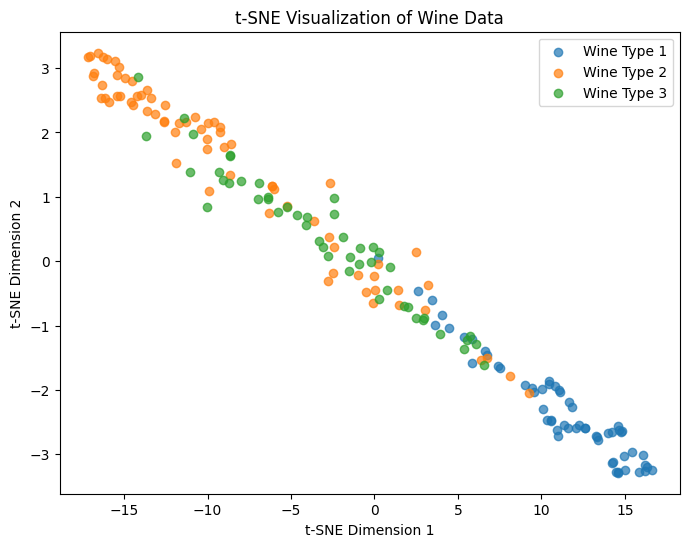

In [45]:
from sklearn.manifold import TSNE
X = wine.drop('Wine', axis=1)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(8, 6))
for wine_type in wine['Wine'].unique():
    plt.scatter(
        X_tsne[wine['Wine'] == wine_type, 0],
        X_tsne[wine['Wine'] == wine_type, 1],
        label=f'Wine Type {wine_type}',
        alpha=0.7
    )

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Wine Data')
plt.legend()
plt.show()

Q10

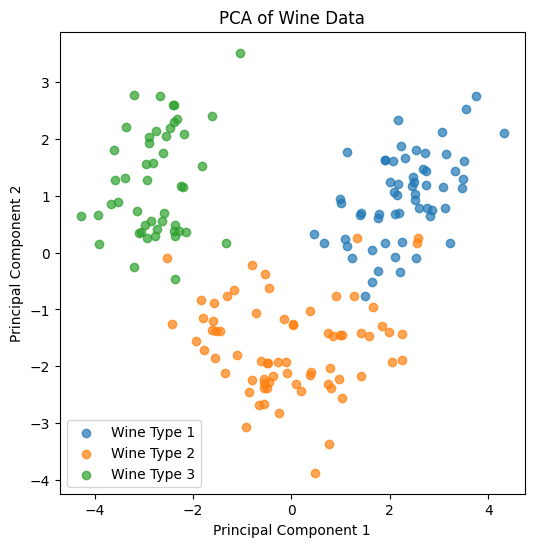

In [59]:
from sklearn.decomposition import PCA
X = wine.drop('Wine', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
principal_df['Wine'] = wine['Wine']
plt.figure(figsize=(6,6))
for wine_type in wine['Wine'].unique():
  plt.scatter(
      principal_df[principal_df['Wine'] == wine_type]['PC1'],
      principal_df[principal_df['Wine'] == wine_type]['PC2'],
      label=f'Wine Type {wine_type}',
      alpha=0.7
  )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Data')
plt.legend()
plt.show()

Q11

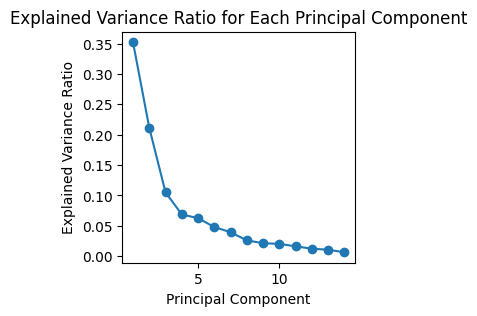

In [55]:
pca = PCA()
pca.fit(X_scaled)
var = pca.explained_variance_ratio_

plt.figure(figsize=(3,3))
plt.plot(range(1, len(var) + 1), var, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio for Each Principal Component')
plt.show()

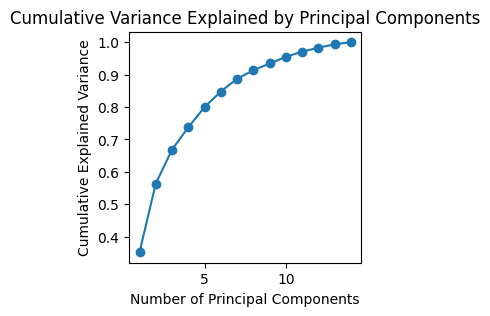

In [52]:
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(3,3))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained by Principal Components')
plt.show()

Feature: Alcohol
25th Percentile: 12.362499999999999
50th Percentile (Median): 13.05
75th Percentile: 13.6775
--------------------


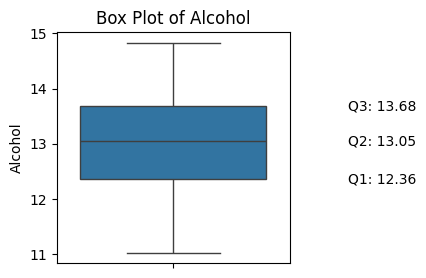

Feature: Malic.acid
25th Percentile: 1.6025
50th Percentile (Median): 1.8650000000000002
75th Percentile: 3.0825
--------------------


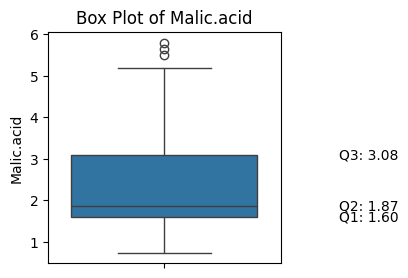

Feature: Phenols
25th Percentile: 1.7425
50th Percentile (Median): 2.355
75th Percentile: 2.8
--------------------


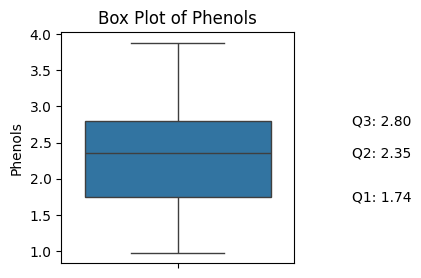

Feature: Proline
25th Percentile: 500.5
50th Percentile (Median): 673.5
75th Percentile: 985.0
--------------------


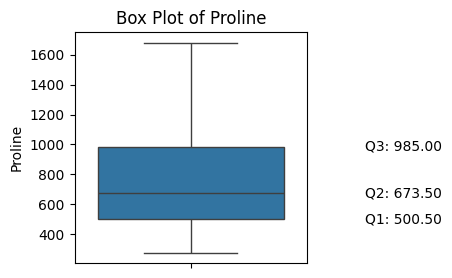

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv"
wine = pd.read_csv(url)

features = ['Alcohol', 'Malic.acid', 'Phenols', 'Proline']

for feature in features:

    percentile_25 = np.percentile(wine[feature], 25)
    percentile_50 = np.percentile(wine[feature], 50)
    percentile_75 = np.percentile(wine[feature], 75)

    print(f"Feature: {feature}")
    print(f"25th Percentile: {percentile_25}")
    print(f"50th Percentile (Median): {percentile_50}")
    print(f"75th Percentile: {percentile_75}")
    print("-" * 20)
    plt.figure(figsize=(3,3))
    sns.boxplot(y=wine[feature])
    plt.ylabel(feature)
    plt.title(f"Box Plot of {feature}")

    # Add labels for quartiles
    plt.text(0.75, percentile_25, f"Q1: {percentile_25:.2f}", ha='left', va='center')
    plt.text(0.75, percentile_50, f"Q2: {percentile_50:.2f}", ha='left', va='center')
    plt.text(0.75, percentile_75, f"Q3: {percentile_75:.2f}", ha='left', va='center')

    plt.show()